In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

party_colours = {
    'PDS': "purple",
    'DIE LINKE': "#BE3075",
    'SPD': "#E3000F",
    'GRÜNE': "#1AA037",
    'FDP':"#FFEF00",
    'CDU': "#000000",
    'CSU': "#0570C9",
    'AfD': "#5B3626",
    'OTHER': "grey"
}

In [2]:
# 1.
#
xml_path = './data_bundestag/mdb-data.xml'
tree = ET.parse(xml_path)
root = tree.getroot()

#
mdbs_data = []
for mdb in root.findall('MDB'):
    info = mdb.find('INFO')
    mdb = {
        'ID': info.findtext('ID'),
        'First_name': info.findtext('First_name'),
        'Last_name': info.findtext('Last_name'),
        'Acad_Title': info.findtext('Acad_Title'),
        'Date_of_birth': info.findtext('Date_of_birth'),
        'Gender': info.findtext('Gender'),
        'Party': info.findtext('Party'),
        'Marital_status': info.findtext('Marital_status'),
        'Children': info.findtext('Children'),
    }
    mdbs_data.append(mdb)

# Converting to DataFrame:
mdbs_df = pd.DataFrame(mdbs_data)

# Data type conversions:
mdbs_df['ID'] = mdbs_df['ID'].astype(int)
mdbs_df['Date_of_birth'] = pd.to_datetime(mdbs_df['Date_of_birth'])
mdbs_df['Children'] = mdbs_df['Children'].astype(int)
mdbs_df['Gender'] = mdbs_df['Gender'].astype('category')
mdbs_df['Party'] = mdbs_df['Party'].astype('category')
mdbs_df['Marital_status'] = mdbs_df['Marital_status'].astype('category')
mdbs_df['Acad_Title'] = mdbs_df['Acad_Title'].fillna('No title')

wp_data = []
for mdb in root.findall('MDB'):
    id = mdb.find('INFO').findtext('ID')
    wplist = mdb.find('WPLIST')
    for wp in wplist.findall('WP'):
        wp_entry = {
            'ID': int(id),
            'WP': int(wp.findtext('WP')),
            'MDBWP_FROM': wp.findtext('MDBWP_FROM'),
            'MDBWP_UNTIL': wp.findtext('MDBWP_UNTIL'),
            'WP_BEGIN': wp.findtext('WP_BEGIN'),
        }
        wp_data.append(wp_entry)

# Converting to DataFrame:
served_terms_df = pd.DataFrame(wp_data)

# Data type conversions:
served_terms_df['MDBWP_FROM'] = pd.to_datetime(served_terms_df['MDBWP_FROM'])
served_terms_df['MDBWP_UNTIL'] = served_terms_df['MDBWP_UNTIL'].apply(
    lambda x: pd.to_datetime(x) if x != '/' else pd.NaT
)   # Handling open-ended dates (marked with "/").
served_terms_df['WP_BEGIN'] = pd.to_datetime(served_terms_df['WP_BEGIN'])

mdbs_df

,ID,First_name,Last_name,Acad_Title,Date_of_birth,Gender,Party,Marital_status,Children
0,11000001,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
1,11000002,Ernst,Achenbach,Dr.,1909-04-09,male,FDP,married,3
2,11000003,Annemarie,Ackermann,None,1913-05-26,female,CDU,married,5
3,11000004,Else,Ackermann,Dr.,1933-11-06,female,CDU,no information / other,0
4,11000005,Ulrich,Adam,None,1950-06-09,male,CDU,married,2
...,...,...,...,...,...,...,...,...,...
4609,11005623,Reza,Asghari,Prof. Dr.,1961-04-01,male,CDU,married,2
4610,11005624,Andrea,Lübcke,Dr.,1978-12-09,female,GRÜNE,no information / other,2
4611,11005625,Lisa,Schubert,None,2002-09-06,diverse,DIE LINKE,no information / other,0
4612,11005626,Mayra,Vriesema,None,1999-12-25,female,GRÜNE,no information / other,0


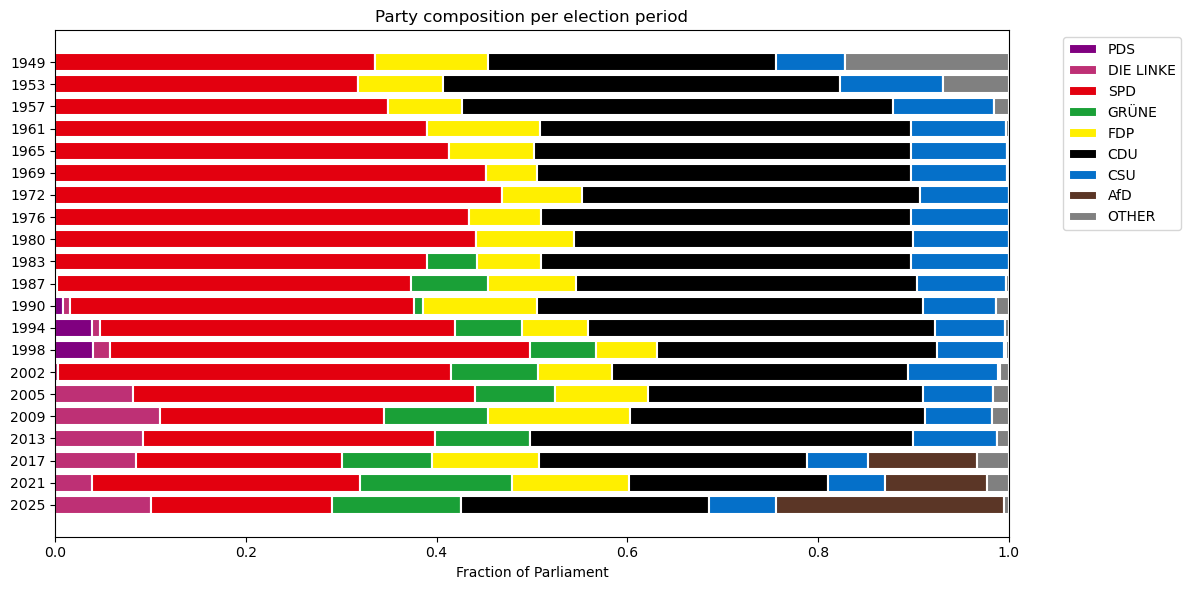

In [3]:
# 2.
# Handling replacement members by calculating fraction of time served in parliament
# relative to the full election period:
wp_df = (
    served_terms_df[['WP', 'WP_BEGIN']]
    .drop_duplicates(subset='WP')
    .sort_values('WP_BEGIN')
    .reset_index(drop=True)
)   # Create an election period DataFrame storing the dates.
wp_df['name'] = wp_df['WP_BEGIN'].dt.year.astype(str)
    # Name election periods after the year they have begun.
wp_end_map = served_terms_df.dropna(subset=['MDBWP_UNTIL']).groupby('WP')['MDBWP_UNTIL'].max()
    # Use the latest observed `MDBWP_UNTIL` per WP as the period end, assuming that at least one MDB per WP finishes his term.
wp_end_map.loc[wp_df.loc[wp_df['WP_BEGIN'] == pd.Timestamp('2025-03-25'), 'WP'].iloc[0]] = pd.Timestamp('2026-07-17')
    # WP 21 uses 2026-07-17 (today) as the end date for fraction calculation.
wp_total_days_map = (wp_end_map - wp_df.set_index('WP')['WP_BEGIN']).dt.days
    # Calculate length of each WP.
wp_end_dates = served_terms_df['WP'].map(wp_end_map)
term_end_dates = served_terms_df['MDBWP_UNTIL'].fillna(wp_end_dates)
    # Handle open-ended terms.
term_length = (term_end_dates - served_terms_df['MDBWP_FROM']).dt.days
    # Calculate total length of each term.
served_terms_df['Frac_of_WP'] = (term_length / served_terms_df['WP'].map(wp_total_days_map)).astype(float)

# Adding party information from mdbs_df to served_terms_df:
served_terms_df = served_terms_df.merge(mdbs_df, on='ID', how='left')

# Aggregate fractions per WP and party:
fractions = served_terms_df.groupby(['WP','Party'])['Frac_of_WP'].sum().unstack(fill_value=0)
for p in party_colours.keys():
    if p not in fractions.columns:
        fractions[p] = 0.0
fractions = fractions[party_colours.keys()]

# Normalize rows to 1 (100% stacked):
fractions_norm = fractions.div(fractions.sum(axis=1).replace({0:1}), axis=0)
wps = fractions_norm.index.tolist()
y_pos = np.arange(len(wps))

# Plot as 100% stacked bar chart:
fig, ax = plt.subplots(figsize=(12, max(6, int(len(wps)*0.25))))
left = np.zeros(len(wps))
for party in party_colours.keys():
    vals = fractions_norm[party].values
    ax.barh(wp_df['name'], vals, left=left, color=party_colours.get(party), edgecolor='white', linewidth=1.5)
    left = left + vals
ax.set_xlabel('Fraction of Parliament')
ax.set_title('Party composition per election period')
ax.set_xlim(0,1)
ax.invert_yaxis()  # show earliest WP at the top
ax.legend(party_colours.keys(), bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# 3.0 def for plotting lines


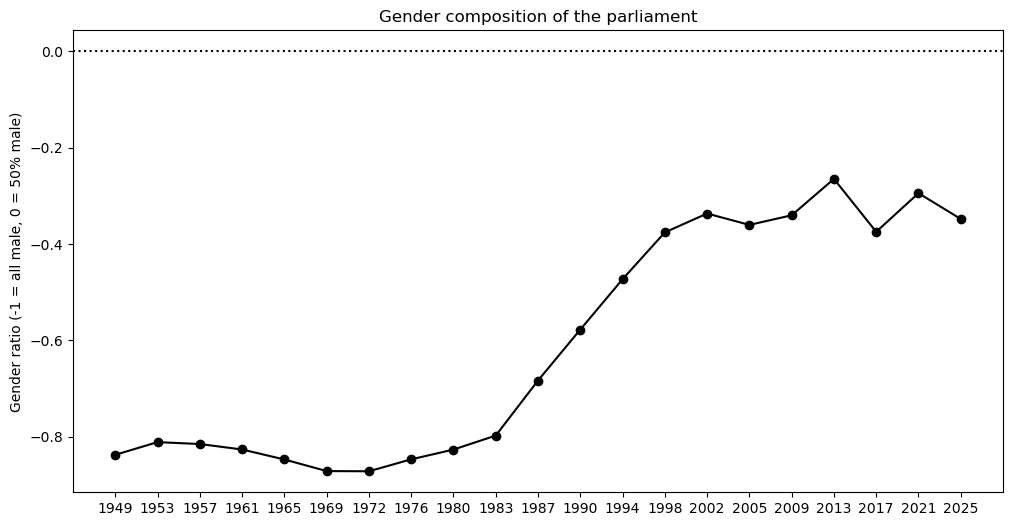

In [4]:
#3.1.
# Weighted gender composition per WP (weighting by Frac_of_WP handles replacement members)
gender_weight = (
    served_terms_df
    .groupby(['WP', 'Gender'])['Frac_of_WP']
    .sum()
    .unstack(fill_value=0)
)

male_share = gender_weight['male'] / gender_weight.sum(axis=1)

# Scale: 0 = 50/50, 1 = all-female, -1 = all-male
gender_ratio = (-2 * (male_share - 0.5)).rename('gender_ratio').reset_index()

# Merge with wp_df to get the year label for each WP
plot_df = wp_df[['WP', 'name']].merge(gender_ratio, on='WP').sort_values('WP')

fig, ax = plt.subplots(figsize=(12, max(6, int(len(plot_df)*0.25))))
ax.plot(plot_df['name'], plot_df['gender_ratio'], marker='o', color='black')
ax.set_ylabel('Gender ratio (-1 = all male, 0 = 50% male)')
ax.set_title('Gender composition of the parliament')
ax.axhline(0, color="black", linestyle=':')
plt.show()

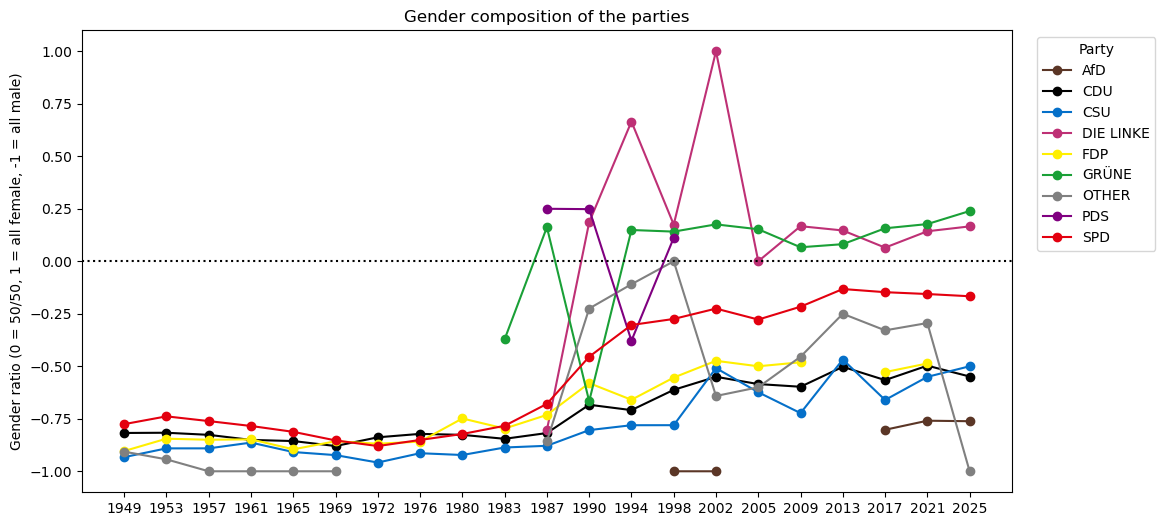

In [5]:
# 3.2.
# Weighted gender composition per WP and party
gender_weight_party = (
    served_terms_df
    .groupby(['WP', 'Party', 'Gender'])['Frac_of_WP']
    .sum()
    .unstack(fill_value=0)
)

male_share_party = gender_weight_party['male'] / gender_weight_party.sum(axis=1)

gender_ratio_party = (-2 * (male_share_party - 0.5)).rename('gender_ratio').reset_index()

# Merge with wp_df to get the year label for each WP
plot_df_party = (
    wp_df[['WP', 'name']]
    .merge(gender_ratio_party, on='WP')
    .sort_values('WP')
)

# Full ordered list of WPs/names, so gaps become NaN instead of being skipped over
full_wp_order = wp_df[['WP', 'name']].sort_values('WP').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, max(6, int(full_wp_order.shape[0] * 0.25))))

for party, group in plot_df_party.groupby('Party'):
    # Reindex to the full WP range; missing WPs become NaN and break the line
    group_full = (
        full_wp_order
        .merge(group[['WP', 'gender_ratio']], on='WP', how='left')
    )
    ax.plot(
        group_full['name'],
        group_full['gender_ratio'],
        marker='o',
        label=party,
        color=party_colours.get(party, 'grey')
    )

ax.set_ylabel('Gender ratio (0 = 50/50, 1 = all female, -1 = all male)')
ax.set_xlabel('')
ax.set_title('Gender composition of the parties')
ax.legend(title='Party', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.axhline(0, color='black', linestyle=':')
plt.show()

In [6]:
served_terms_df

,ID,WP,MDBWP_FROM,MDBWP_UNTIL,WP_BEGIN,Frac_of_WP,First_name,Last_name,Acad_Title,Date_of_birth,Gender,Party,Marital_status,Children
0,11000001,5,1965-10-19,1969-10-19,1965-10-19,1.000000,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
1,11000001,6,1969-10-20,1972-09-22,1969-10-20,1.000000,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
2,11000001,7,1972-12-13,1976-12-13,1972-12-13,0.999316,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
3,11000001,8,1976-12-14,1980-11-04,1976-12-14,1.000000,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
4,11000001,9,1980-11-04,1983-03-29,1980-11-04,1.000000,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13041,11005623,21,2025-06-10,NaT,2025-03-25,0.839248,Reza,Asghari,Prof. Dr.,1961-04-01,male,CDU,married,2
13042,11005624,21,2025-07-01,NaT,2025-03-25,0.795407,Andrea,Lübcke,Dr.,1978-12-09,female,GRÜNE,no information / other,2
13043,11005625,21,2025-08-01,NaT,2025-03-25,0.730689,Lisa,Schubert,None,2002-09-06,diverse,DIE LINKE,no information / other,0
13044,11005626,21,2025-09-01,NaT,2025-03-25,0.665971,Mayra,Vriesema,None,1999-12-25,female,GRÜNE,no information / other,0
